In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import mediapipe as mp
import sklearn
import xgboost as xgb

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("OpenCV:", cv2.__version__)
print("MediaPipe:", mp.__version__)
print("Scikit-learn:", sklearn.__version__)
print("XGBoost:", xgb.__version__)

print("\nML environment is ready ✅")

NumPy: 2.5.2
Pandas: 3.0.5
OpenCV: 5.0.0
MediaPipe: 1.0.1
Scikit-learn: 1.9.0
XGBoost: 3.4.1

ML environment is ready ✅


In [1]:
from pathlib import Path

# Dataset path
TRAIN_DIR = Path(
    "../data/raw/asl_alphabet/"
    "asl_alphabet_train/asl_alphabet_train"
)

# Get class folders
classes = sorted([
    folder.name
    for folder in TRAIN_DIR.iterdir()
    if folder.is_dir()
])

# Count images in each class
class_counts = {}

for class_name in classes:
    class_folder = TRAIN_DIR / class_name

    image_count = len([
        file for file in class_folder.iterdir()
        if file.is_file()
    ])

    class_counts[class_name] = image_count

print("Number of classes:", len(classes))
print("Classes:", classes)
print("Total training images:", sum(class_counts.values()))

class_counts

Number of classes: 29
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
Total training images: 87000


{'A': 3000,
 'B': 3000,
 'C': 3000,
 'D': 3000,
 'E': 3000,
 'F': 3000,
 'G': 3000,
 'H': 3000,
 'I': 3000,
 'J': 3000,
 'K': 3000,
 'L': 3000,
 'M': 3000,
 'N': 3000,
 'O': 3000,
 'P': 3000,
 'Q': 3000,
 'R': 3000,
 'S': 3000,
 'T': 3000,
 'U': 3000,
 'V': 3000,
 'W': 3000,
 'X': 3000,
 'Y': 3000,
 'Z': 3000,
 'del': 3000,
 'nothing': 3000,
 'space': 3000}

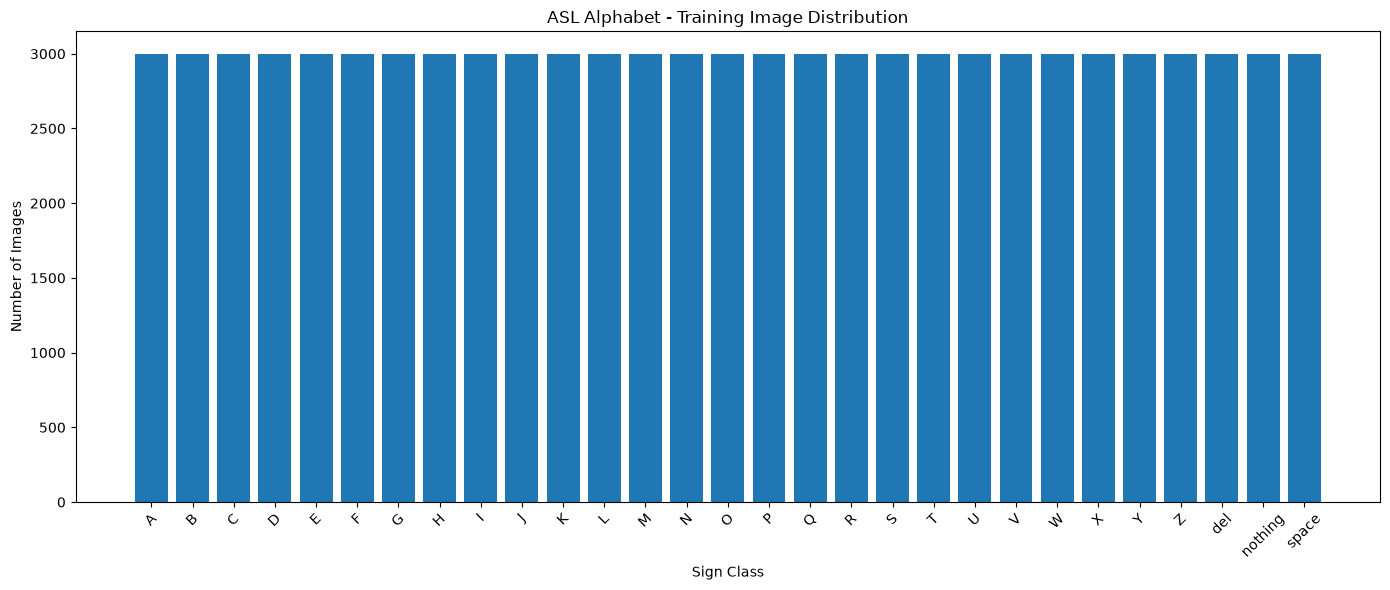

In [4]:
# Visualize class distribution

plt.figure(figsize=(14, 6))

plt.bar(class_counts.keys(), class_counts.values())

plt.title("ASL Alphabet - Training Image Distribution")
plt.xlabel("Sign Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

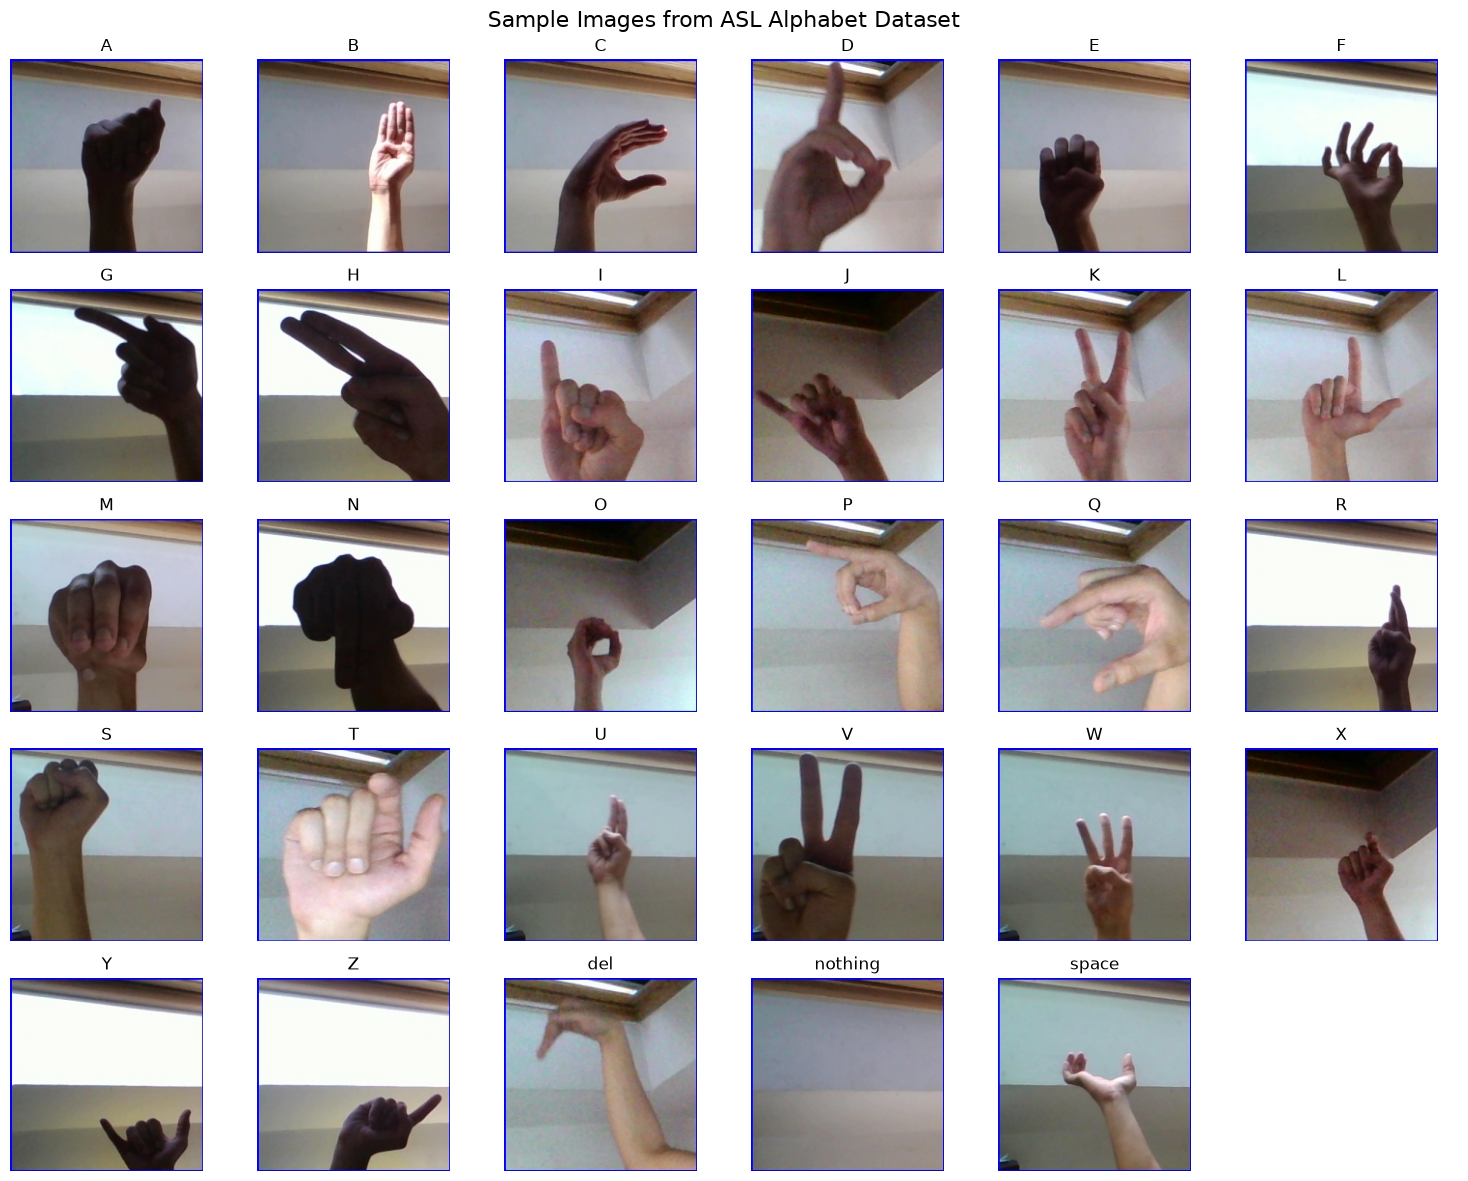

In [5]:
# Display one sample image from each ASL class

fig, axes = plt.subplots(5, 6, figsize=(15, 12))
axes = axes.flatten()

for i, class_name in enumerate(classes):
    class_folder = TRAIN_DIR / class_name

    # Select the first image
    image_path = next(class_folder.iterdir())

    # Read image using OpenCV
    image = cv2.imread(str(image_path))

    # Convert BGR to RGB for Matplotlib
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    axes[i].imshow(image)
    axes[i].set_title(class_name)
    axes[i].axis("off")

# Hide unused subplot
for i in range(len(classes), len(axes)):
    axes[i].axis("off")

plt.suptitle("Sample Images from ASL Alphabet Dataset", fontsize=16)
plt.tight_layout()
plt.show()

In [6]:
# Inspect image properties

sample_class = classes[0]
sample_folder = TRAIN_DIR / sample_class
sample_path = next(sample_folder.iterdir())

sample_image = cv2.imread(str(sample_path))

print("Sample class:", sample_class)
print("Image path:", sample_path)
print("Image shape:", sample_image.shape)
print("Image height:", sample_image.shape[0])
print("Image width:", sample_image.shape[1])
print("Number of channels:", sample_image.shape[2])
print("Data type:", sample_image.dtype)
print("Minimum pixel value:", sample_image.min())
print("Maximum pixel value:", sample_image.max())

Sample class: A
Image path: ../data/raw/asl_alphabet/asl_alphabet_train/asl_alphabet_train/A/A25.jpg
Image shape: (200, 200, 3)
Image height: 200
Image width: 200
Number of channels: 3
Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255


In [8]:
# Check image dimensions across the dataset

image_shapes = set()
checked_images = 0

for class_name in classes:
    class_folder = TRAIN_DIR / class_name

    # Check first 100 images from each class
    for image_path in list(class_folder.iterdir())[:100]:
        image = cv2.imread(str(image_path))

        if image is not None:
            image_shapes.add(image.shape)
            checked_images += 1

print("Images checked:", checked_images)
print("Unique image shapes:", image_shapes)

Images checked: 2900
Unique image shapes: {(200, 200, 3)}


In [9]:
# Check dataset for corrupted or unreadable images

corrupted_images = []
total_checked = 0

for class_name in classes:
    class_folder = TRAIN_DIR / class_name

    for image_path in class_folder.iterdir():

        if not image_path.is_file():
            continue

        image = cv2.imread(str(image_path))
        total_checked += 1

        if image is None:
            corrupted_images.append(str(image_path))

print("Total images checked:", total_checked)
print("Corrupted/unreadable images:", len(corrupted_images))

if corrupted_images:
    print("\nCorrupted files:")
    for path in corrupted_images[:20]:
        print(path)
else:
    print("Dataset integrity check passed ✅")

Total images checked: 87000
Corrupted/unreadable images: 0
Dataset integrity check passed ✅


In [10]:
# Analyze pixel intensity distribution

pixel_values = []

# Sample 20 images from each class
for class_name in classes:
    class_folder = TRAIN_DIR / class_name

    for image_path in list(class_folder.iterdir())[:20]:
        image = cv2.imread(str(image_path))

        if image is not None:
            pixel_values.extend(image.flatten())

pixel_values = np.array(pixel_values)

print("Pixels analyzed:", len(pixel_values))
print("Minimum:", pixel_values.min())
print("Maximum:", pixel_values.max())
print("Mean:", round(pixel_values.mean(), 2))
print("Standard deviation:", round(pixel_values.std(), 2))

Pixels analyzed: 69600000
Minimum: 0
Maximum: 255
Mean: 130.72
Standard deviation: 63.22


In [11]:
# Inspect ASL test dataset

TEST_DIR = Path(
    "../data/raw/asl_alphabet/"
    "asl_alphabet_test/asl_alphabet_test"
)

test_images = [
    file for file in TEST_DIR.iterdir()
    if file.is_file()
]

print("Number of test images:", len(test_images))
print("\nTest files:")

for file in sorted(test_images):
    print(file.name)

Number of test images: 28

Test files:
A_test.jpg
B_test.jpg
C_test.jpg
D_test.jpg
E_test.jpg
F_test.jpg
G_test.jpg
H_test.jpg
I_test.jpg
J_test.jpg
K_test.jpg
L_test.jpg
M_test.jpg
N_test.jpg
O_test.jpg
P_test.jpg
Q_test.jpg
R_test.jpg
S_test.jpg
T_test.jpg
U_test.jpg
V_test.jpg
W_test.jpg
X_test.jpg
Y_test.jpg
Z_test.jpg
nothing_test.jpg
space_test.jpg


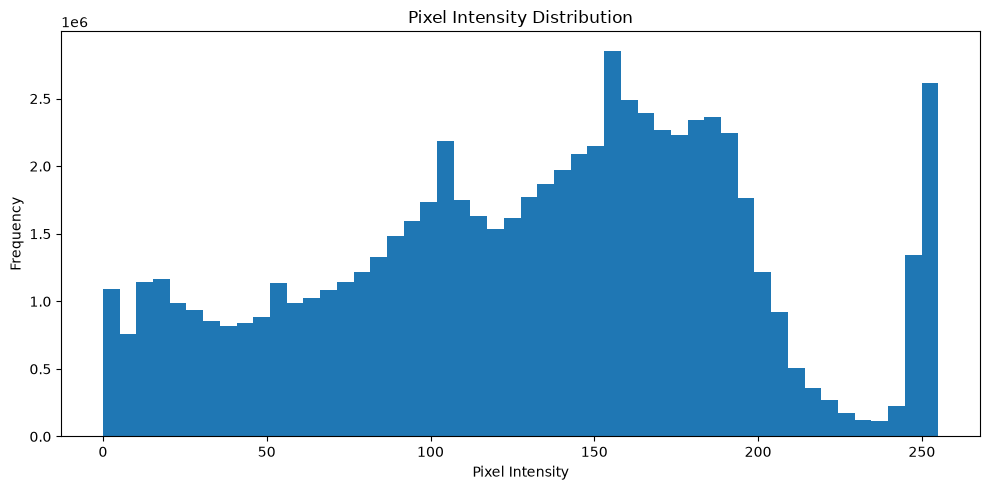

In [12]:
# Pixel intensity distribution

plt.figure(figsize=(10, 5))

plt.hist(
    pixel_values,
    bins=50,
    range=(0, 255)
)

plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()